# ETAIQ - Exploratory Data Analysis (EDA)

This notebook contains the complete Exploratory Data Analysis (EDA) for the ETAIQ project. It analyzes the cleaned datasets generated by the Decision Engine, Cleaning Engine, and Validation Engine and prepares the data for machine learning model development.

# 1. Introduction

## Project Overview

ETAIQ is an end-to-end machine learning system designed to predict food delivery Estimated Time of Arrival (ETA). Before building the prediction model, the project first focuses on ensuring high-quality data through a complete data quality pipeline consisting of the Decision Engine, Cleaning Engine, and Validation Engine. Only the validated processed datasets are used for exploratory analysis and subsequent machine learning tasks.

## Business Problem

Accurate delivery estimates are essential for customer satisfaction and reliable operations. Restaurants depend on efficient order management, delivery partners benefit from realistic routing expectations, and incorrect ETA predictions reduce both customer satisfaction and operational efficiency.

## Objective of this Notebook

This notebook performs Exploratory Data Analysis (EDA) on the cleaned datasets in order to understand the datasets, verify overall data quality, study feature distributions, identify relationships between variables, discover meaningful business insights, and assess readiness for machine learning.

## Datasets Used

| Dataset | Description |
|----------|-------------|
| restaurants.csv | Restaurant information including location and operational attributes |
| riders.csv | Rider information including experience and delivery-related attributes |
| orders.csv | Historical delivery orders containing the target variable and predictive features |

## Expected Outcome

By the end of this notebook, the cleaned datasets will be fully understood, important statistical properties will be analyzed, visualizations will reveal useful patterns, potential predictive features will be identified, and the datasets will be confirmed to be ready for machine learning model development.

# 2. Import Libraries

This section imports the core libraries used throughout the notebook for data manipulation, numerical computation, data visualization, and file handling.

In [19]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Configure notebook display
# -------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# -------------------------------
# Configure plotting
# -------------------------------
plt.style.use("default")
sns.set_theme(style="whitegrid")

# -------------------------------
# Locate project root automatically
# -------------------------------
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "ml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate the project root containing the 'ml' directory."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "ml" / "reports"

# Verify directories exist
assert DATA_DIR.exists(), f"Processed data directory not found: {DATA_DIR}"
assert REPORTS_DIR.exists(), f"Reports directory not found: {REPORTS_DIR}"

# -------------------------------
# Display Environment Information
# -------------------------------
print("=" * 80)
print("ETAIQ Environment Information")
print("=" * 80)
print(f"Project Root  : {PROJECT_ROOT}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version : {np.__version__}")
print(f"Processed Data: {DATA_DIR}")
print(f"Reports Folder: {REPORTS_DIR}")
print("=" * 80)

ETAIQ Environment Information
Project Root  : /Users/kaloha/ETAIQ
Pandas Version: 3.0.3
NumPy Version : 2.4.6
Processed Data: /Users/kaloha/ETAIQ/ml/data/processed
Reports Folder: /Users/kaloha/ETAIQ/ml/reports


# 3. Load Processed Datasets

This section loads the cleaned datasets generated by the Cleaning Engine. These processed datasets have already passed all validation checks and achieved a data quality score of 100%. Every subsequent analysis in this notebook uses these processed datasets.

The notebook loads:

- restaurants.csv
- riders.csv
- orders.csv

from:

ml/data/processed/

In [20]:
from pathlib import Path

import pandas as pd

# Create paths for processed datasets
restaurants_path = DATA_DIR / "restaurants.csv"
riders_path = DATA_DIR / "riders.csv"
orders_path = DATA_DIR / "orders.csv"

# Verify that every file exists
required_files = {
    "Restaurants": restaurants_path,
    "Riders": riders_path,
    "Orders": orders_path,
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required file for {name}: {path}")

# Load the CSV files into DataFrames
restaurants_df = pd.read_csv(restaurants_path)
riders_df = pd.read_csv(riders_path)
orders_df = pd.read_csv(orders_path)

# Print dataset summary
print("=" * 50)
print("Processed Dataset Summary")
print("=" * 50)
print(f"Restaurants : {restaurants_df.shape[0]} rows × {restaurants_df.shape[1]} columns")
print(f"Riders : {riders_df.shape[0]} rows × {riders_df.shape[1]} columns")
print(f"Orders : {orders_df.shape[0]} rows × {orders_df.shape[1]} columns")
print("=" * 50)
print("All processed datasets loaded successfully.")

Processed Dataset Summary
Restaurants : 3917 rows × 8 columns
Riders : 5832 rows × 8 columns
Orders : 264777 rows × 12 columns
All processed datasets loaded successfully.


# 4. Dataset Overview

Before performing any statistical analysis or visualization, it is important to understand the structure of each dataset.

This section examines:

- Dataset dimensions
- Column names
- Data types
- Memory usage
- Numerical and categorical columns
- First few records

Understanding the dataset structure helps identify potential feature types and provides confidence that the processed datasets are ready for detailed analysis.

In [21]:
from IPython.display import display

for name, df in [("Restaurants", restaurants_df), ("Riders", riders_df), ("Orders", orders_df)]:
    print("=" * 60)
    print(f"{name} Dataset")
    print("=" * 60)
    print(f"Dataset Name: {name}")
    print(f"Shape:")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print("\nColumn Names:")
    print(df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

    print(f"\nNumerical Columns: {len(numeric_cols)}")
    print(f"Categorical Columns: {len(categorical_cols)}")
    print("\nFirst 5 Rows:")
    display(df.head())
    print("\n")

Restaurants Dataset
Dataset Name: Restaurants
Shape:
Rows: 3917
Columns: 8

Column Names:
['id', 'name', 'lat', 'lon', 'cuisine', 'avg_rating', 'prep_capacity', 'manager_contact']

Data Types:
id                   int64
name                   str
lat                float64
lon                float64
cuisine                str
avg_rating         float64
prep_capacity        int64
manager_contact        str
dtype: object

Memory Usage: 0.92 MB

Numerical Columns: 5
Categorical Columns: 3

First 5 Rows:


,id,name,lat,lon,cuisine,avg_rating,prep_capacity,manager_contact
0,1,Green Bites,12.9761,77.5794,Italian,3.0000,15,+91-922575562
1,2,Spice Diner,12.9626,77.5948,Italian,4.3000,10,+91-931429110
2,3,Tandoor Bites,12.9779,77.5895,Biryani,3.6000,8,+91-771662963
3,4,Madras House,12.9728,77.6097,Continental,4.1000,20,+91-710024741
4,5,Urban Eats,12.9768,77.6033,Italian,3.6000,10,+91-999949389




Riders Dataset
Dataset Name: Riders
Shape:
Rows: 5832
Columns: 8

Column Names:
['id', 'lat', 'lon', 'vehicle_type', 'completed_orders', 'shift_hours', 'current_load', 'rider_call_sign']

Data Types:
id                    int64
lat                 float64
lon                 float64
vehicle_type            str
completed_orders      int64
shift_hours         float64
current_load          int64
rider_call_sign         str
dtype: object

Memory Usage: 0.96 MB

Numerical Columns: 6
Categorical Columns: 2

First 5 Rows:


,id,lat,lon,vehicle_type,completed_orders,shift_hours,current_load,rider_call_sign
0,2,12.9536,77.6048,car,82,6.3000,0,KR-271
1,3,12.9561,77.5854,bike,397,8.1000,0,WY-778
2,4,12.9739,77.5833,Scooter,1320,6.4000,3,QJ-190
3,5,12.9537,77.5802,scooter,308,9.3000,1,FN-723
4,6,12.9555,77.5920,BIKE,35,0.2000,2,QU-908




Orders Dataset
Dataset Name: Orders
Shape:
Rows: 264777
Columns: 12

Column Names:
['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size', 'order_value', 'timestamp', 'promised_eta', 'actual_delivery_time_min', 'order_status', 'promo_code_used']

Data Types:
id                            int64
restaurant_id                 int64
rider_id                      int64
drop_lat                    float64
drop_lon                    float64
order_size                    int64
order_value                 float64
timestamp                       str
promised_eta                float64
actual_delivery_time_min    float64
order_status                    str
promo_code_used                 str
dtype: object

Memory Usage: 69.99 MB

Numerical Columns: 9
Categorical Columns: 3

First 5 Rows:


,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,order_status,promo_code_used
0,1,1921,5764,12.9672,77.6014,7,843.8600,2026-05-06 19:22:36,15.0000,22.2000,delivered,BLR10
1,2,417,3377,12.9856,77.6152,1,156.3700,2026-05-18 22:56:00,15.0000,19.2000,delivered,WELCOME50
2,3,692,3424,12.9566,77.6083,2,290.1500,2026-06-05 19:20:00,20.0000,20.1000,delivered,WELCOME50
3,4,140,861,12.9501,77.5902,2,164.7700,2026-05-16 19:39:57,20.0000,18.6000,delivered,BLR10
4,5,189,4881,12.9723,77.5796,2,384.4600,2026-05-19 19:50:36,20.0000,20.1000,delivered,BLR10


# 5. Data Quality Assessment

Before exploring patterns in the data, it is essential to verify that the processed datasets are clean and reliable.

Although the Cleaning Engine and Validation Engine have already produced datasets with a final quality score of 100/100, this section independently verifies the processed data by examining common quality indicators.

The following checks are performed for each dataset:

- Missing values
- Duplicate records
- Unique values
- Data completeness
- Overall quality summary

This serves as an additional verification step before statistical analysis and machine learning.

In [22]:
import pandas as pd

quality_rows = []

for name, df in [("Restaurants", restaurants_df), ("Riders", riders_df), ("Orders", orders_df)]:
    print("=" * 80)
    print(f"{name} Dataset Quality Assessment")
    print("=" * 80)

    # 1. Missing values
    total_missing = int(df.isnull().sum().sum())
    missing_per_column = df.isnull().sum()
    missing_percentage = (missing_per_column / len(df) * 100).round(2)

    if total_missing == 0:
        print("Missing Values:")
        print("No missing values detected.")
    else:
        print("Missing Values:")
        print("Total Missing Values:", total_missing)
        print("Missing Values per Column:")
        display(pd.DataFrame({"Missing Values": missing_per_column, "Missing Percentage (%)": missing_percentage}))

    # 2. Duplicate records
    duplicate_count = int(df.duplicated().sum())
    if duplicate_count == 0:
        print("\nDuplicate Records:")
        print("No duplicate rows detected.")
    else:
        print("\nDuplicate Records:")
        print(f"Total Duplicate Rows: {duplicate_count}")

    # 3. Unique values summary
    unique_summary = pd.DataFrame({
        "Column Name": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Unique Values": [df[col].nunique(dropna=True) for col in df.columns],
        "Missing Values": df.isnull().sum().values,
        "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2).values,
    })

    print("\nUnique Values Summary:")
    display(unique_summary)

    # 4. Dataset completeness
    total_cells = df.shape[0] * df.shape[1]
    non_missing_cells = total_cells - total_missing
    completeness_pct = round((non_missing_cells / total_cells) * 100, 2)

    print(f"\nCompleteness (%): {completeness_pct:.2f}%")

    # 5. Quality summary
    quality_rows.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": total_missing,
        "Duplicate Rows": duplicate_count,
        "Completeness (%)": completeness_pct,
    })

    print("\n")

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

Restaurants Dataset Quality Assessment
Missing Values:
No missing values detected.

Duplicate Records:
No duplicate rows detected.

Unique Values Summary:


,Column Name,Data Type,Unique Values,Missing Values,Missing Percentage
id,id,int64,3917,0,0.0000
name,name,str,225,0,0.0000
lat,lat,float64,3689,0,0.0000
lon,lon,float64,3686,0,0.0000
cuisine,cuisine,str,10,0,0.0000
avg_rating,avg_rating,float64,22,0,0.0000
prep_capacity,prep_capacity,int64,8,0,0.0000
manager_contact,manager_contact,str,3380,0,0.0000



Completeness (%): 100.00%


Riders Dataset Quality Assessment
Missing Values:
Total Missing Values: 215
Missing Values per Column:


,Missing Values,Missing Percentage (%)
id,0,0.0000
lat,0,0.0000
lon,0,0.0000
vehicle_type,215,3.6900
completed_orders,0,0.0000
shift_hours,0,0.0000
current_load,0,0.0000
rider_call_sign,0,0.0000



Duplicate Records:
No duplicate rows detected.

Unique Values Summary:


,Column Name,Data Type,Unique Values,Missing Values,Missing Percentage
id,id,int64,5832,0,0.0000
lat,lat,float64,5405,0,0.0000
lon,lon,float64,5414,0,0.0000
vehicle_type,vehicle_type,str,14,215,3.6900
completed_orders,completed_orders,int64,1981,0,0.0000
shift_hours,shift_hours,float64,126,0,0.0000
current_load,current_load,int64,7,0,0.0000
rider_call_sign,rider_call_sign,str,5254,0,0.0000



Completeness (%): 99.54%


Orders Dataset Quality Assessment
Missing Values:
No missing values detected.

Duplicate Records:
No duplicate rows detected.

Unique Values Summary:


,Column Name,Data Type,Unique Values,Missing Values,Missing Percentage
id,id,int64,264777,0,0.0000
restaurant_id,restaurant_id,int64,3917,0,0.0000
rider_id,rider_id,int64,5832,0,0.0000
drop_lat,drop_lat,float64,43887,0,0.0000
drop_lon,drop_lon,float64,43892,0,0.0000
order_size,order_size,int64,9,0,0.0000
order_value,order_value,float64,91126,0,0.0000
timestamp,timestamp,str,229147,0,0.0000
promised_eta,promised_eta,float64,7,0,0.0000
actual_delivery_time_min,actual_delivery_time_min,float64,1109,0,0.0000



Completeness (%): 100.00%




,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Completeness (%)
0,Restaurants,3917,8,0,0,100.0000
1,Riders,5832,8,215,0,99.5400
2,Orders,264777,12,0,0,100.0000


# 6. Descriptive Statistics

Descriptive statistics provide a high-level understanding of the numerical features in the processed datasets.

This section summarizes the central tendency, spread, and distribution of numerical variables. These statistics help identify the scale of features, detect unusual values, and understand the overall characteristics of the cleaned data before visualization and machine learning.

The analysis includes:

- Count
- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Quartiles (25%, 50%, 75%)
- Variance
- Skewness
- Kurtosis

These metrics provide a statistical foundation for subsequent exploratory analysis.

In [23]:
for name, df in [("Restaurants", restaurants_df), ("Riders", riders_df), ("Orders", orders_df)]:
    print("=" * 80)
    print(f"{name} Dataset — Descriptive Statistics")
    print("=" * 80)

    numeric_df = df.select_dtypes(include=["number"])

    if numeric_df.empty:
        print("No numerical columns available for descriptive statistics.")
        continue

    stats = numeric_df.describe().T
    stats["Variance"] = numeric_df.var(ddof=1)
    stats["Skewness"] = numeric_df.skew()
    stats["Kurtosis"] = numeric_df.kurt()

    stats = stats.round(2)
    display(stats)

    print(f"\nTotal numerical features analyzed: {len(numeric_df.columns)}")
    print("Numerical features:")
    print(list(numeric_df.columns))
    print("\n")

Restaurants Dataset — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
id,3917.0000,2000.9000,1154.6300,1.0000,1001.0000,1998.0000,3003.0000,4000.0000,1333165.7900,-0.0000,-1.2000
lat,3917.0000,12.9700,0.0100,12.9600,12.9600,12.9700,12.9800,12.9900,0.0000,-0.0200,-1.2100
lon,3917.0000,77.5900,0.0100,77.5800,77.5900,77.5900,77.6000,77.6100,0.0000,0.0400,-1.1900
avg_rating,3917.0000,3.8500,0.5900,2.8000,3.4000,3.8000,4.3000,4.9000,0.3400,0.0200,-1.0400
prep_capacity,3917.0000,10.4200,5.3800,0.0000,6.0000,10.0000,15.0000,20.0000,28.9300,0.3500,-0.7100



Total numerical features analyzed: 5
Numerical features:
['id', 'lat', 'lon', 'avg_rating', 'prep_capacity']


Riders Dataset — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
id,5832.0000,2995.5700,1732.5600,2.0000,1492.7500,2990.5000,4496.2500,6000.0000,3001747.9600,0.0000,-1.2000
lat,5832.0000,12.9700,0.0100,12.9500,12.9600,12.9700,12.9800,12.9900,0.0000,-0.0200,-1.2200
lon,5832.0000,77.5900,0.0100,77.5700,77.5800,77.5900,77.6000,77.6100,0.0000,0.0000,-1.2100
completed_orders,5832.0000,846.1500,1146.1600,0.0000,38.0000,289.0000,1337.2500,3997.0000,1313687.2700,1.3500,0.4100
shift_hours,5832.0000,5.5100,3.2200,0.0000,2.7000,5.5000,8.3000,15.9000,10.3900,0.0800,-1.0200
current_load,5832.0000,1.4300,1.3800,-1.0000,0.0000,1.0000,2.0000,5.0000,1.9100,0.7200,-0.2300



Total numerical features analyzed: 6
Numerical features:
['id', 'lat', 'lon', 'completed_orders', 'shift_hours', 'current_load']


Orders Dataset — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
id,264777.0000,149987.3100,86590.5300,1.0000,74911.0000,149971.0000,224988.0000,300000.0000,7497920435.9400,0.0000,-1.2000
restaurant_id,264777.0000,1995.6100,1153.4400,1.0000,1001.0000,1996.0000,2993.0000,4000.0000,1330434.4600,0.0000,-1.2000
rider_id,264777.0000,2992.3300,1695.6400,2.0000,1559.0000,3000.0000,4424.0000,6000.0000,2875211.4600,0.0000,-1.1200
drop_lat,264777.0000,12.9700,0.0100,12.9500,12.9600,12.9700,12.9800,12.9900,0.0000,0.0000,-1.2000
drop_lon,264777.0000,77.5900,0.0100,77.5700,77.5800,77.5900,77.6100,77.6200,0.0000,0.0000,-1.1900
order_size,264777.0000,2.8400,1.7200,0.0000,1.0000,2.0000,4.0000,8.0000,2.9400,0.8300,0.0200
order_value,264777.0000,433.8800,273.4800,0.0100,213.1500,373.3200,594.7400,1296.2700,74788.6400,0.9400,0.2700
promised_eta,264777.0000,21.6300,6.2900,10.0000,15.0000,20.0000,25.0000,40.0000,39.5600,0.5700,0.1200
actual_delivery_time_min,264777.0000,25.5600,9.5100,8.0000,19.8000,24.4000,29.7000,137.2000,90.4000,2.8000,19.0800



Total numerical features analyzed: 9
Numerical features:
['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size', 'order_value', 'promised_eta', 'actual_delivery_time_min']




# 7. Univariate Analysis

Univariate analysis studies each feature independently to understand its distribution, frequency, spread, and overall behavior.

This analysis helps identify:

- Feature distributions
- Data concentration
- Skewed variables
- Potential outliers
- Class imbalance
- Characteristics of categorical variables

These insights are useful before studying relationships between variables.

Restaurants Dataset — Univariate Analysis

Numerical Features

--------------------------------------------------------------------------------
Feature : id
--------------------------------------------------------------------------------


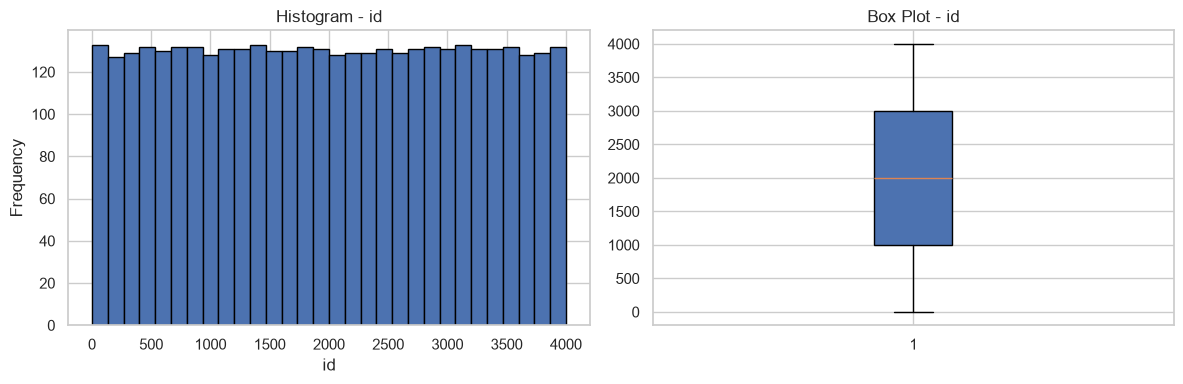

,Statistic,Value
0,Minimum,1.0000
1,Maximum,4000.0000
2,Mean,2000.9000
3,Median,1998.0000
4,Standard Deviation,1154.6300
5,Skewness,-0.0000
6,Kurtosis,-1.2000



--------------------------------------------------------------------------------
Feature : lat
--------------------------------------------------------------------------------


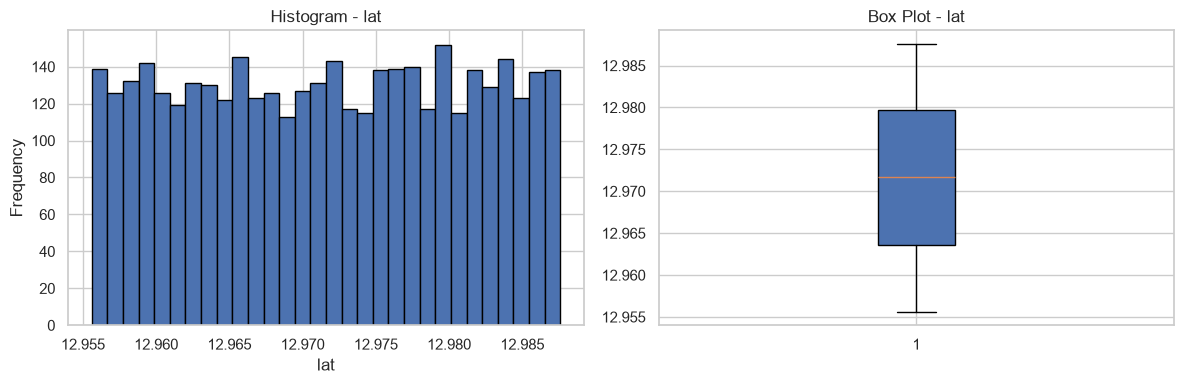

,Statistic,Value
0,Minimum,12.9600
1,Maximum,12.9900
2,Mean,12.9700
3,Median,12.9700
4,Standard Deviation,0.0100
5,Skewness,-0.0200
6,Kurtosis,-1.2100



--------------------------------------------------------------------------------
Feature : lon
--------------------------------------------------------------------------------


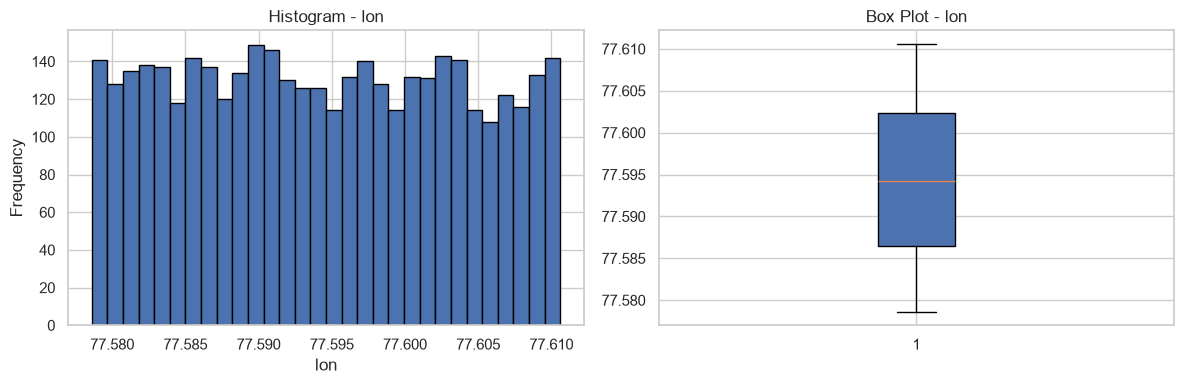

,Statistic,Value
0,Minimum,77.5800
1,Maximum,77.6100
2,Mean,77.5900
3,Median,77.5900
4,Standard Deviation,0.0100
5,Skewness,0.0400
6,Kurtosis,-1.1900



--------------------------------------------------------------------------------
Feature : avg_rating
--------------------------------------------------------------------------------


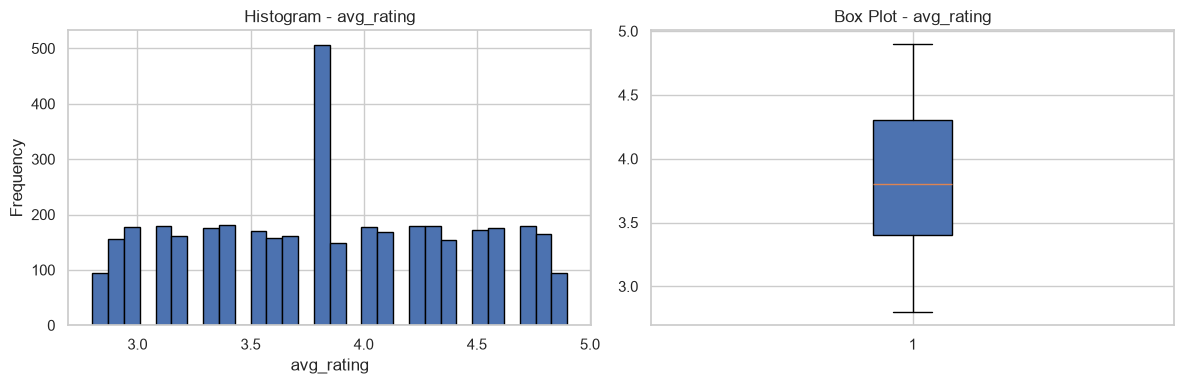

,Statistic,Value
0,Minimum,2.8000
1,Maximum,4.9000
2,Mean,3.8500
3,Median,3.8000
4,Standard Deviation,0.5900
5,Skewness,0.0200
6,Kurtosis,-1.0400



--------------------------------------------------------------------------------
Feature : prep_capacity
--------------------------------------------------------------------------------


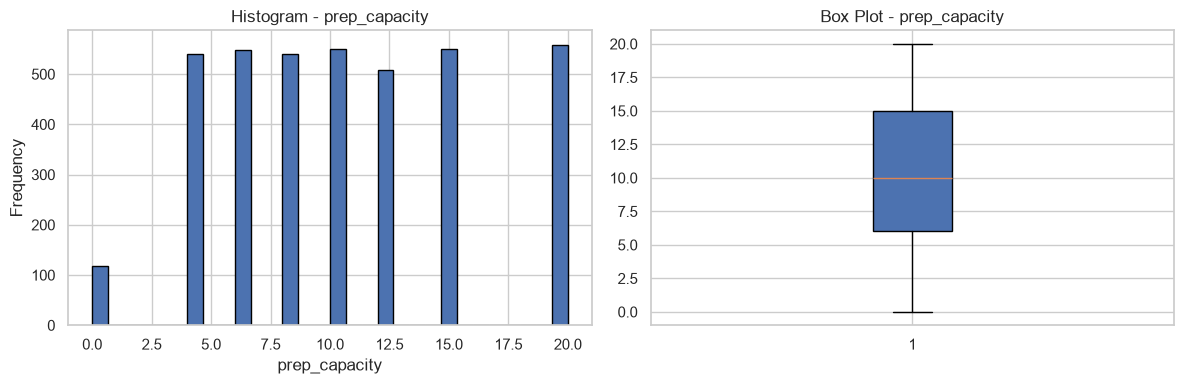

,Statistic,Value
0,Minimum,0.0000
1,Maximum,20.0000
2,Mean,10.4200
3,Median,10.0000
4,Standard Deviation,5.3800
5,Skewness,0.3500
6,Kurtosis,-0.7100



Categorical Features

--------------------------------------------------------------------------------
Feature : name
--------------------------------------------------------------------------------


,Count,Percentage (%)
name,,
Urban Diner,34,0.8700
Garden Hub,31,0.7900
Wok Junction,28,0.7100
Bombay Express,28,0.7100
Bombay Diner,27,0.6900
...,...,...
Garden Bites,10,0.2600
Namma Bistro,9,0.2300
Green Diner,9,0.2300


name has 225 unique values.
Displaying Top 10 categories only.



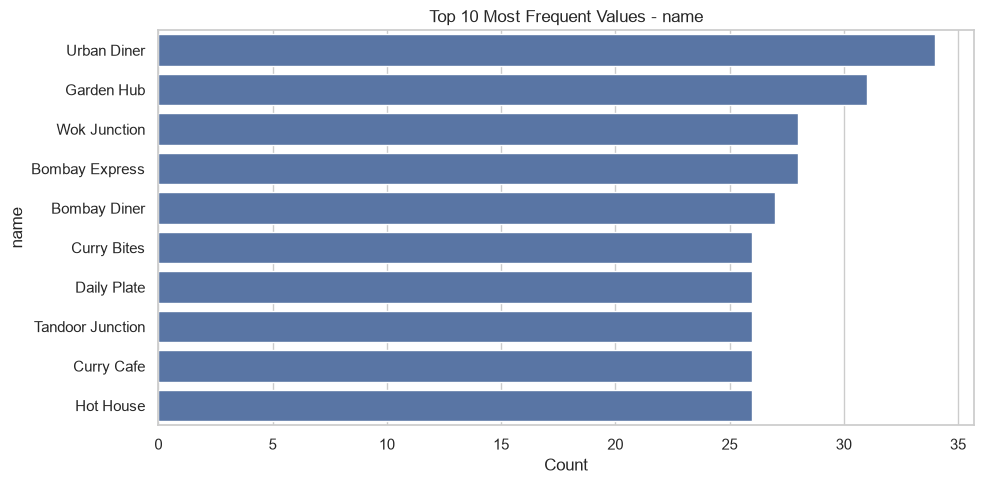


--------------------------------------------------------------------------------
Feature : cuisine
--------------------------------------------------------------------------------


,Count,Percentage (%)
cuisine,,
Bakery & Desserts,442,11.2800
Italian,429,10.9500
Healthy Bowls,411,10.4900
North Indian,402,10.2600
Continental,389,9.9300
Fast Food,382,9.7500
Beverages,372,9.5000
South Indian,371,9.4700
Chinese,366,9.3400


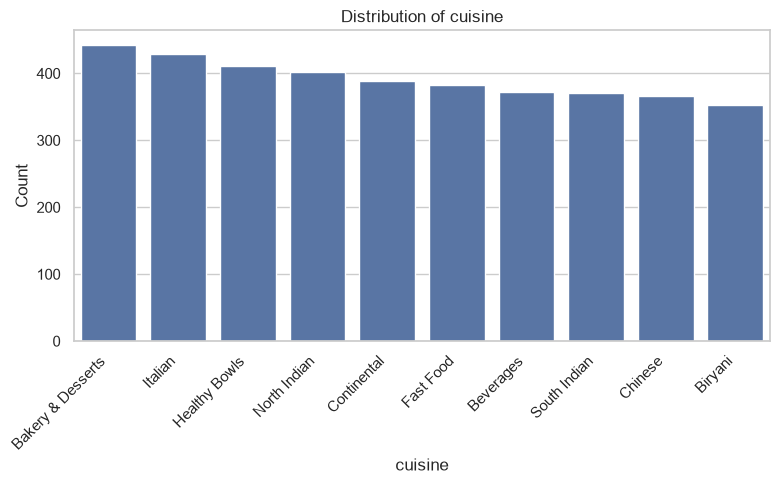


--------------------------------------------------------------------------------
Feature : manager_contact
--------------------------------------------------------------------------------


,Count,Percentage (%)
manager_contact,,
+91-710024741,538,13.7400
+91-922575562,1,0.0300
+91-931429110,1,0.0300
+91-771662963,1,0.0300
+91-999949389,1,0.0300
...,...,...
+91-795936983,1,0.0300
+91-966455296,1,0.0300
+91-939963430,1,0.0300


manager_contact has 3380 unique values.
Displaying Top 10 categories only.



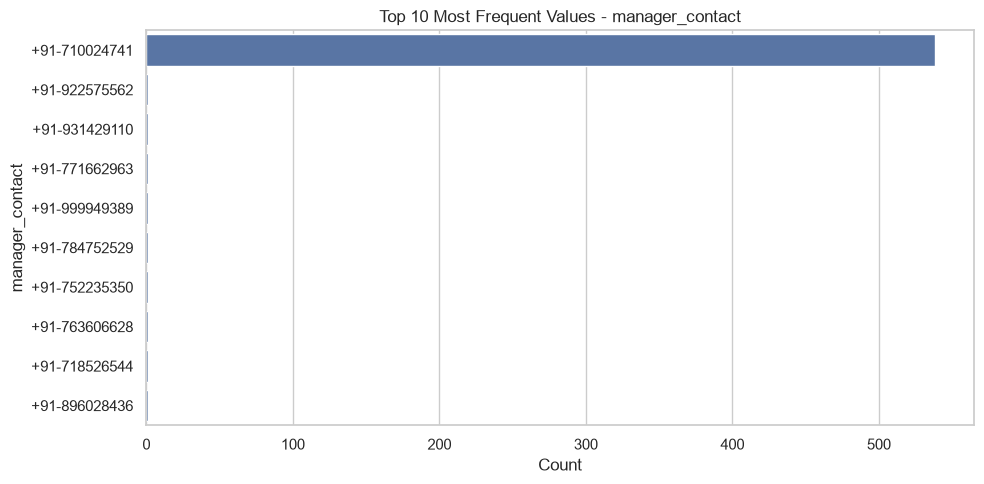



Riders Dataset — Univariate Analysis

Numerical Features

--------------------------------------------------------------------------------
Feature : id
--------------------------------------------------------------------------------


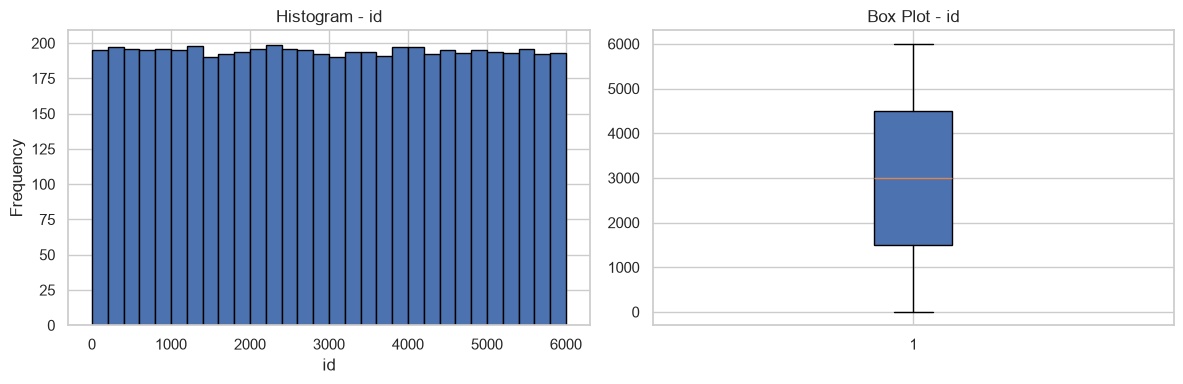

,Statistic,Value
0,Minimum,2.0000
1,Maximum,6000.0000
2,Mean,2995.5700
3,Median,2990.5000
4,Standard Deviation,1732.5600
5,Skewness,0.0000
6,Kurtosis,-1.2000



--------------------------------------------------------------------------------
Feature : lat
--------------------------------------------------------------------------------


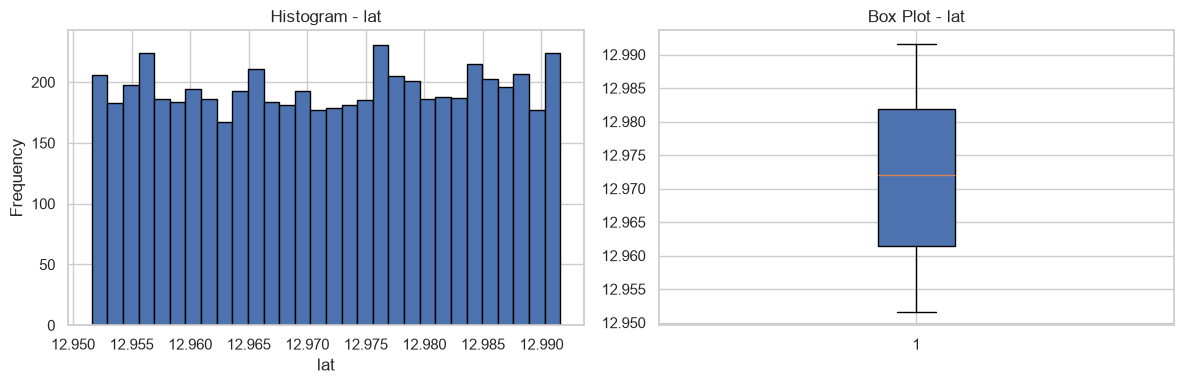

,Statistic,Value
0,Minimum,12.9500
1,Maximum,12.9900
2,Mean,12.9700
3,Median,12.9700
4,Standard Deviation,0.0100
5,Skewness,-0.0200
6,Kurtosis,-1.2200



--------------------------------------------------------------------------------
Feature : lon
--------------------------------------------------------------------------------


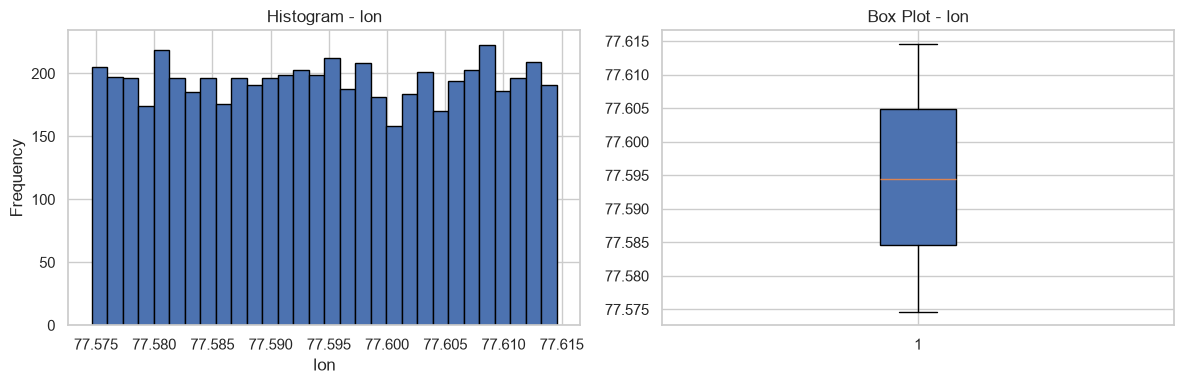

,Statistic,Value
0,Minimum,77.5700
1,Maximum,77.6100
2,Mean,77.5900
3,Median,77.5900
4,Standard Deviation,0.0100
5,Skewness,0.0000
6,Kurtosis,-1.2100



--------------------------------------------------------------------------------
Feature : completed_orders
--------------------------------------------------------------------------------


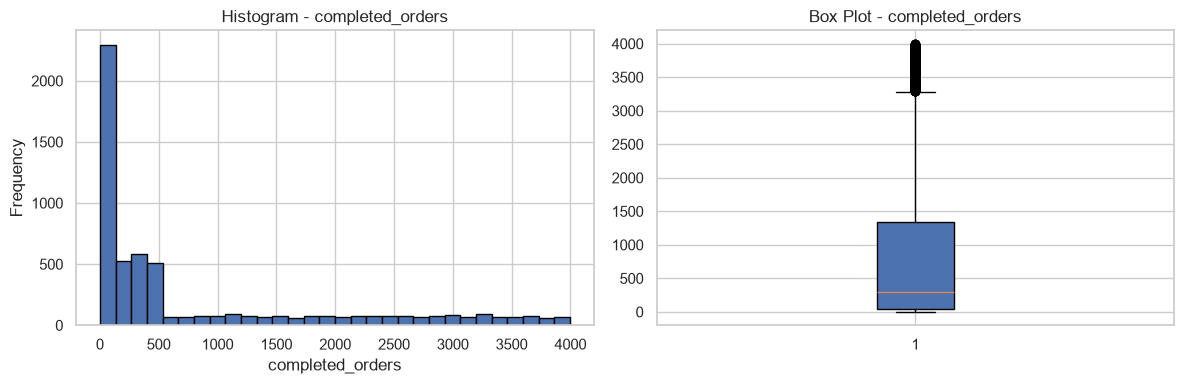

,Statistic,Value
0,Minimum,0.0000
1,Maximum,3997.0000
2,Mean,846.1500
3,Median,289.0000
4,Standard Deviation,1146.1600
5,Skewness,1.3500
6,Kurtosis,0.4100



--------------------------------------------------------------------------------
Feature : shift_hours
--------------------------------------------------------------------------------


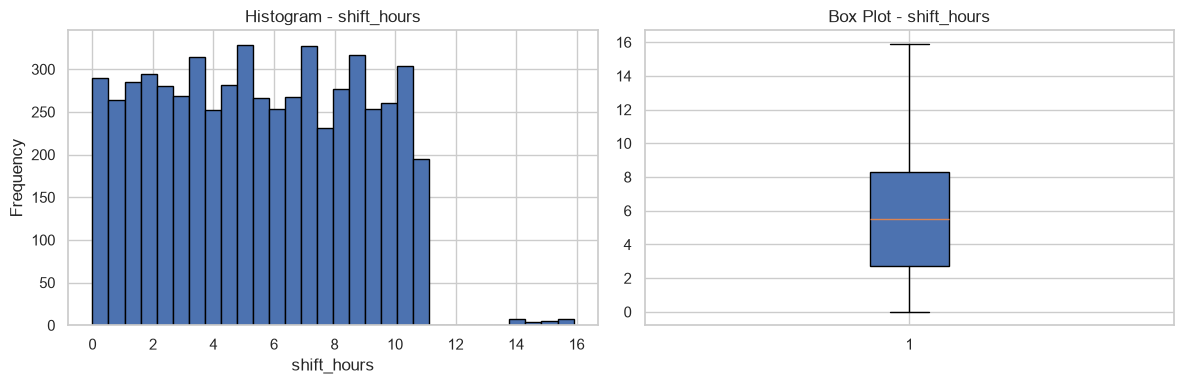

,Statistic,Value
0,Minimum,0.0000
1,Maximum,15.9000
2,Mean,5.5100
3,Median,5.5000
4,Standard Deviation,3.2200
5,Skewness,0.0800
6,Kurtosis,-1.0200



--------------------------------------------------------------------------------
Feature : current_load
--------------------------------------------------------------------------------


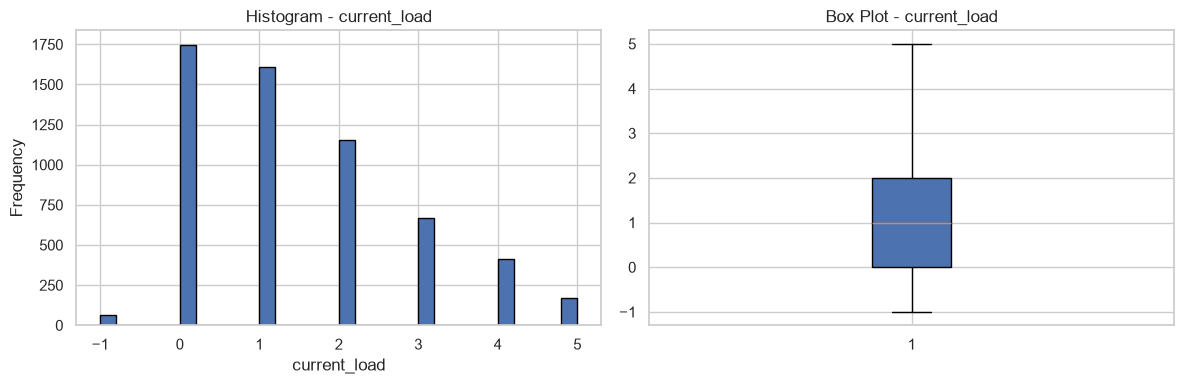

,Statistic,Value
0,Minimum,-1.0000
1,Maximum,5.0000
2,Mean,1.4300
3,Median,1.0000
4,Standard Deviation,1.3800
5,Skewness,0.7200
6,Kurtosis,-0.2300



Categorical Features

--------------------------------------------------------------------------------
Feature : vehicle_type
--------------------------------------------------------------------------------


,Count,Percentage (%)
vehicle_type,,
cycle,485,8.3200
Scooter,470,8.0600
scooter,468,8.0200
e-scooter,459,7.8700
bicycle,457,7.8400
Bicycle,434,7.4400
CAR,377,6.4600
Car,371,6.3600
BIKE,357,6.1200


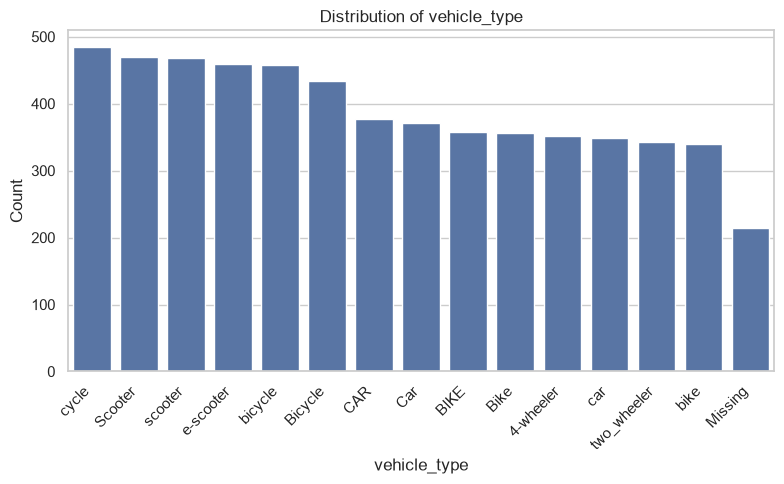


--------------------------------------------------------------------------------
Feature : rider_call_sign
--------------------------------------------------------------------------------


,Count,Percentage (%)
rider_call_sign,,
EC-821,552,9.4700
QB-455,2,0.0300
RT-734,2,0.0300
UV-549,2,0.0300
GX-332,2,0.0300
...,...,...
XD-534,1,0.0200
JF-178,1,0.0200
VU-845,1,0.0200


rider_call_sign has 5254 unique values.
Displaying Top 10 categories only.



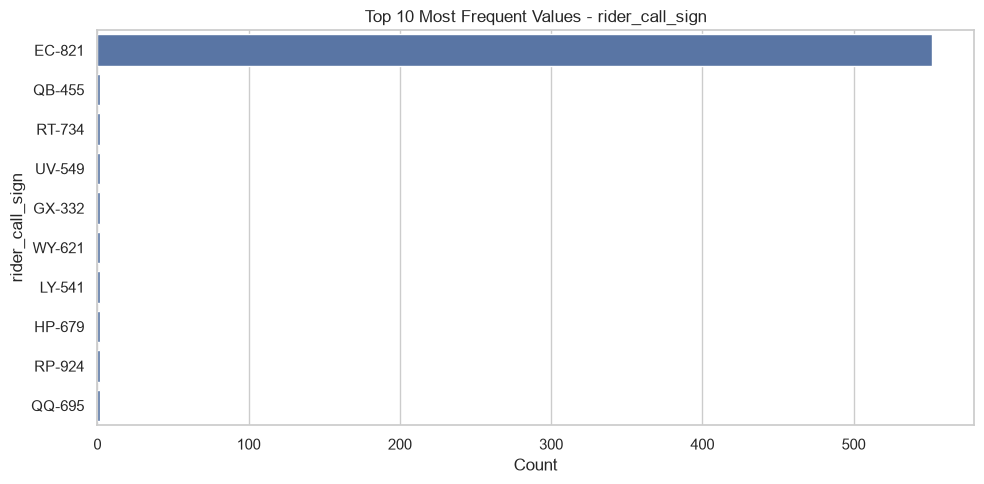



Orders Dataset — Univariate Analysis

Numerical Features

--------------------------------------------------------------------------------
Feature : id
--------------------------------------------------------------------------------


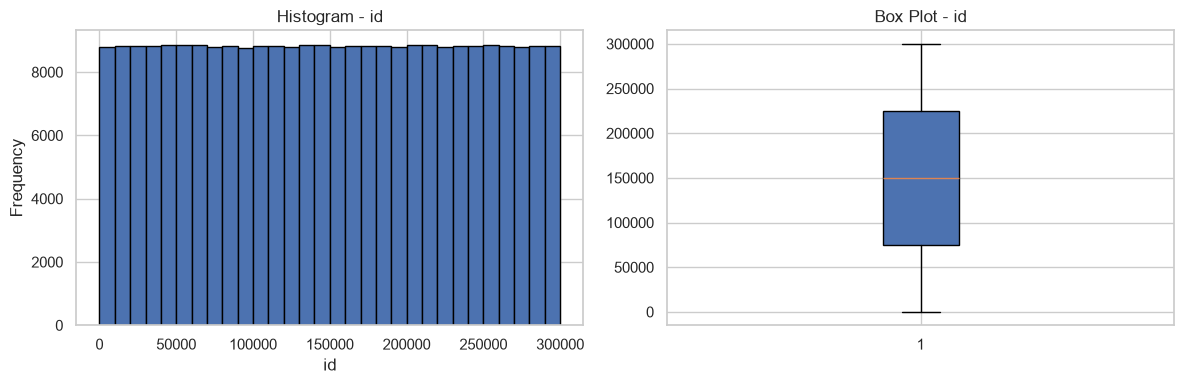

,Statistic,Value
0,Minimum,1.0000
1,Maximum,300000.0000
2,Mean,149987.3100
3,Median,149971.0000
4,Standard Deviation,86590.5300
5,Skewness,0.0000
6,Kurtosis,-1.2000



--------------------------------------------------------------------------------
Feature : restaurant_id
--------------------------------------------------------------------------------


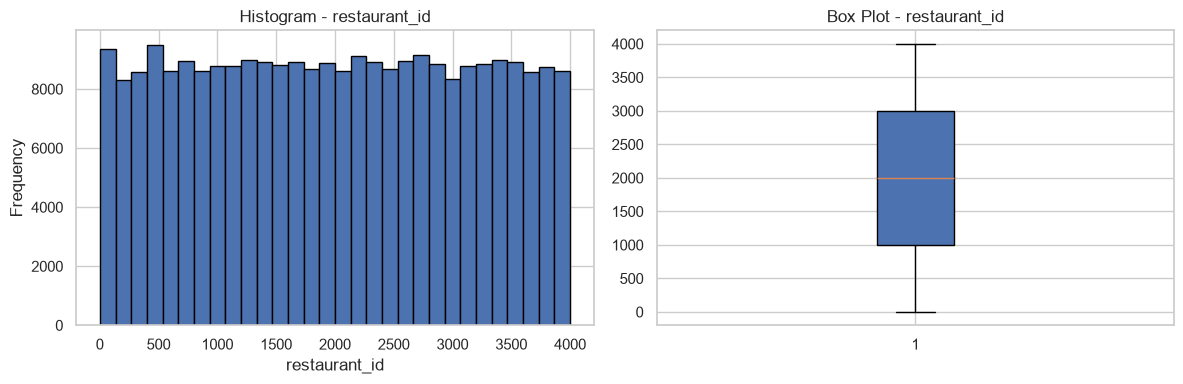

,Statistic,Value
0,Minimum,1.0000
1,Maximum,4000.0000
2,Mean,1995.6100
3,Median,1996.0000
4,Standard Deviation,1153.4400
5,Skewness,0.0000
6,Kurtosis,-1.2000



--------------------------------------------------------------------------------
Feature : rider_id
--------------------------------------------------------------------------------


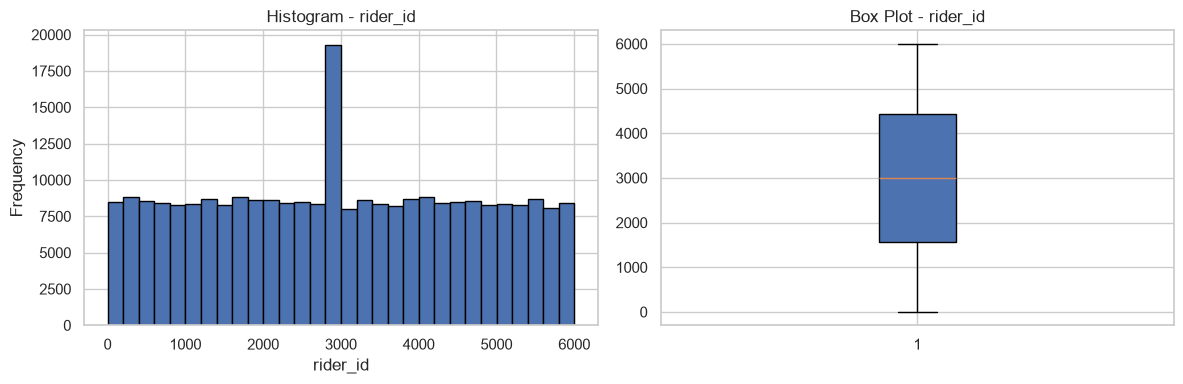

,Statistic,Value
0,Minimum,2.0000
1,Maximum,6000.0000
2,Mean,2992.3300
3,Median,3000.0000
4,Standard Deviation,1695.6400
5,Skewness,0.0000
6,Kurtosis,-1.1200



--------------------------------------------------------------------------------
Feature : drop_lat
--------------------------------------------------------------------------------


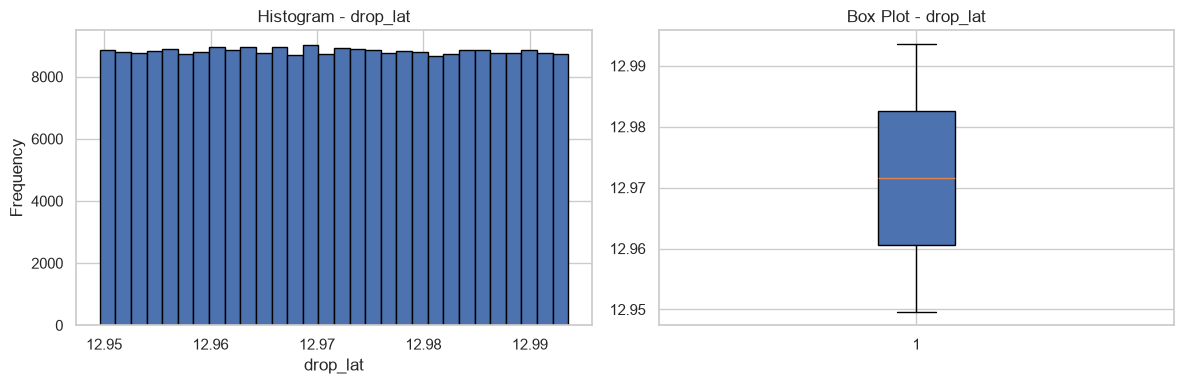

,Statistic,Value
0,Minimum,12.9500
1,Maximum,12.9900
2,Mean,12.9700
3,Median,12.9700
4,Standard Deviation,0.0100
5,Skewness,0.0000
6,Kurtosis,-1.2000



--------------------------------------------------------------------------------
Feature : drop_lon
--------------------------------------------------------------------------------


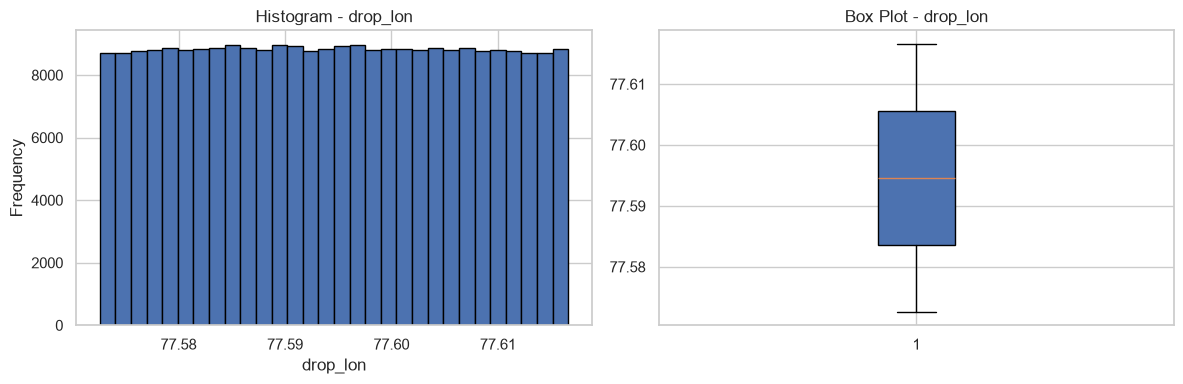

,Statistic,Value
0,Minimum,77.5700
1,Maximum,77.6200
2,Mean,77.5900
3,Median,77.5900
4,Standard Deviation,0.0100
5,Skewness,0.0000
6,Kurtosis,-1.1900



--------------------------------------------------------------------------------
Feature : order_size
--------------------------------------------------------------------------------


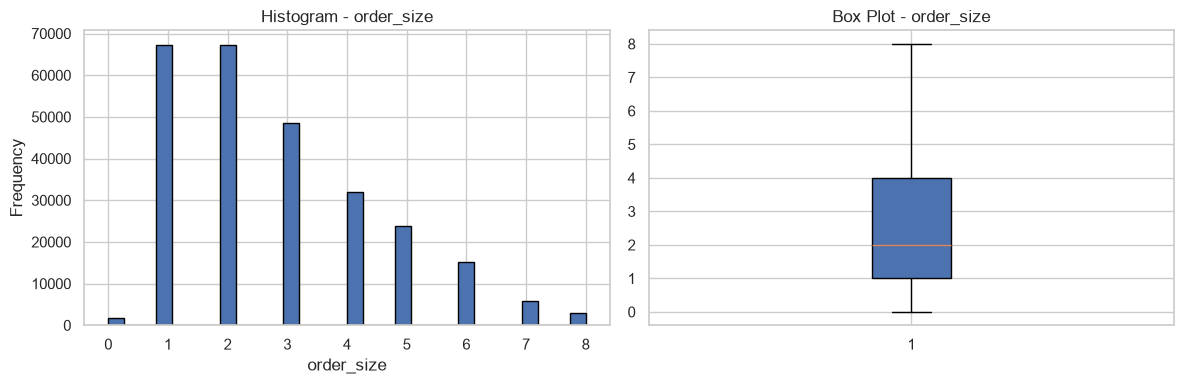

,Statistic,Value
0,Minimum,0.0000
1,Maximum,8.0000
2,Mean,2.8400
3,Median,2.0000
4,Standard Deviation,1.7200
5,Skewness,0.8300
6,Kurtosis,0.0200



--------------------------------------------------------------------------------
Feature : order_value
--------------------------------------------------------------------------------


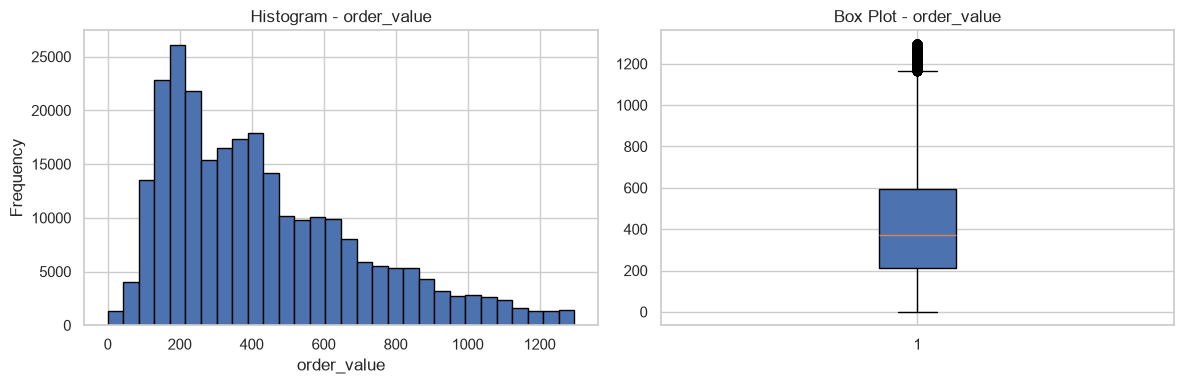

,Statistic,Value
0,Minimum,0.0100
1,Maximum,1296.2700
2,Mean,433.8800
3,Median,373.3200
4,Standard Deviation,273.4800
5,Skewness,0.9400
6,Kurtosis,0.2700



--------------------------------------------------------------------------------
Feature : promised_eta
--------------------------------------------------------------------------------


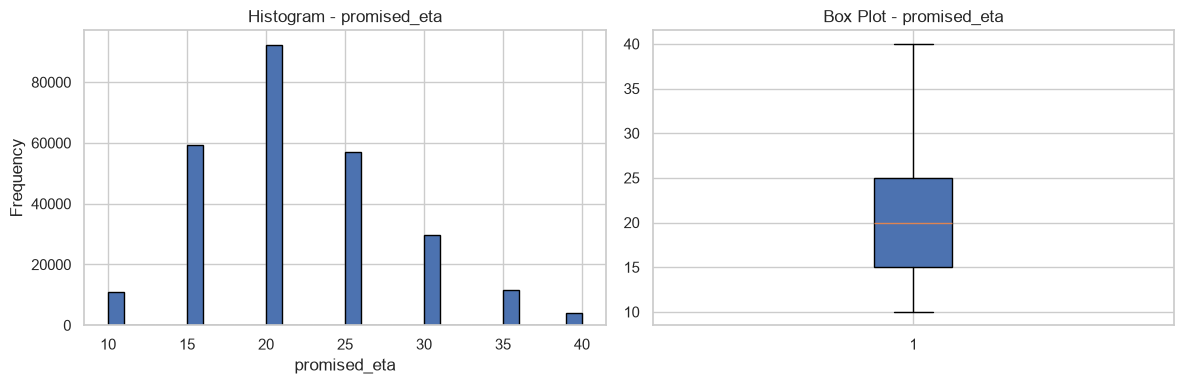

,Statistic,Value
0,Minimum,10.0000
1,Maximum,40.0000
2,Mean,21.6300
3,Median,20.0000
4,Standard Deviation,6.2900
5,Skewness,0.5700
6,Kurtosis,0.1200



--------------------------------------------------------------------------------
Feature : actual_delivery_time_min
--------------------------------------------------------------------------------


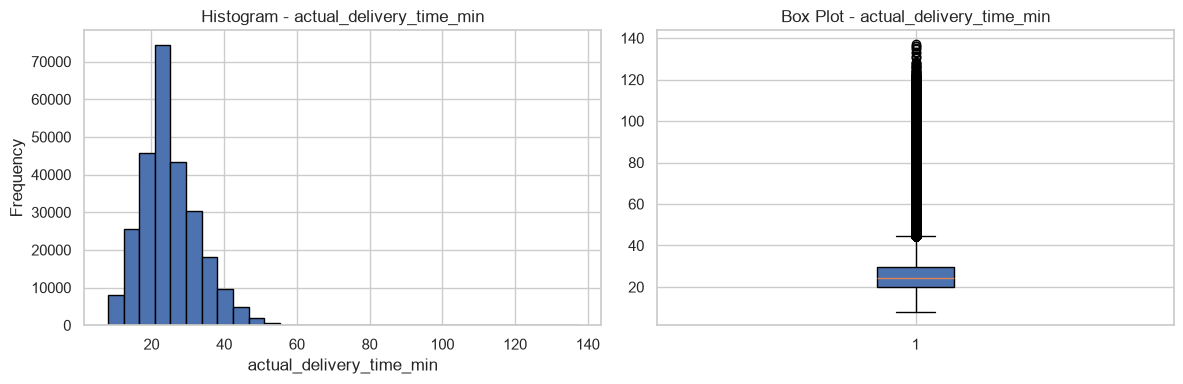

,Statistic,Value
0,Minimum,8.0000
1,Maximum,137.2000
2,Mean,25.5600
3,Median,24.4000
4,Standard Deviation,9.5100
5,Skewness,2.8000
6,Kurtosis,19.0800



Categorical Features

--------------------------------------------------------------------------------
Feature : timestamp
--------------------------------------------------------------------------------


,Count,Percentage (%)
timestamp,,
2026-06-22 20:19:00,11,0.0000
2026-06-19 12:00:00,10,0.0000
2026-06-15 12:56:00,9,0.0000
2026-06-14 19:29:00,9,0.0000
2026-06-02 20:30:00,9,0.0000
...,...,...
2026-06-05 12:08:56,1,0.0000
2026-06-24 13:58:07,1,0.0000
2026-06-21 21:41:04,1,0.0000


timestamp has 229147 unique values.
Displaying Top 10 categories only.



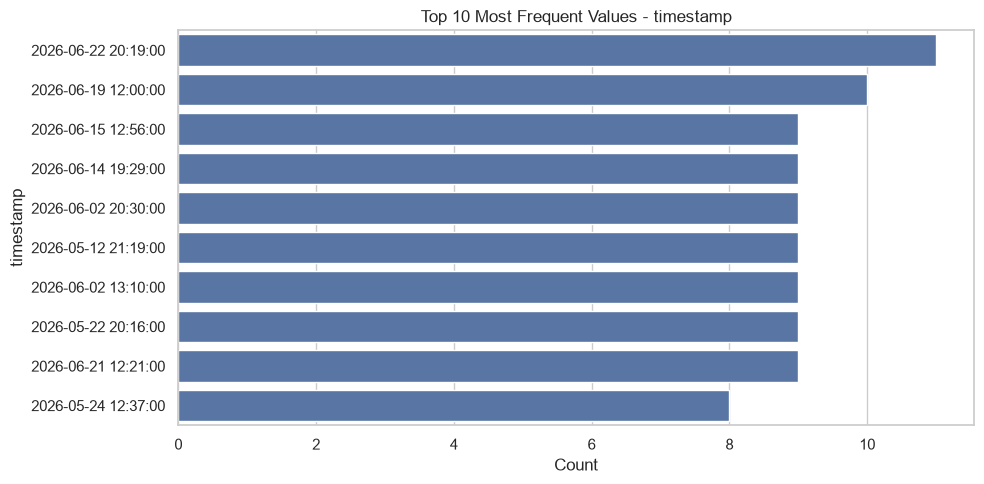


--------------------------------------------------------------------------------
Feature : order_status
--------------------------------------------------------------------------------


,Count,Percentage (%)
order_status,,
delivered,246177,92.9800
cancelled,18600,7.0200


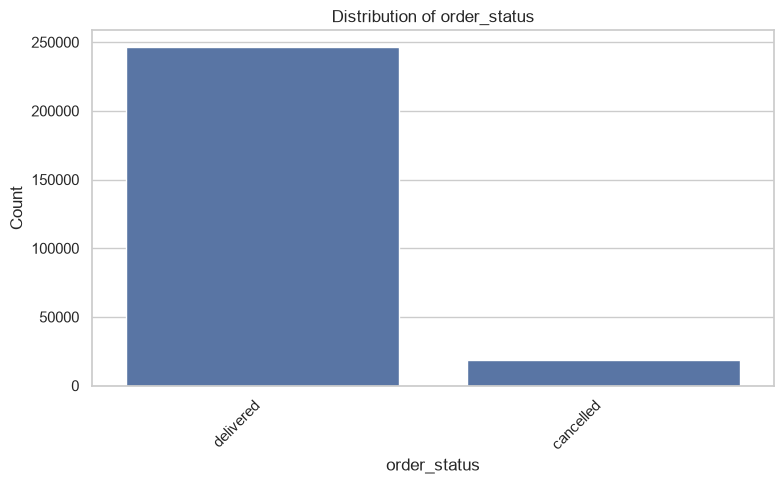


--------------------------------------------------------------------------------
Feature : promo_code_used
--------------------------------------------------------------------------------


,Count,Percentage (%)
promo_code_used,,
BLR10,176820,66.7800
WELCOME50,44045,16.6300
FREESHIP,43912,16.5800


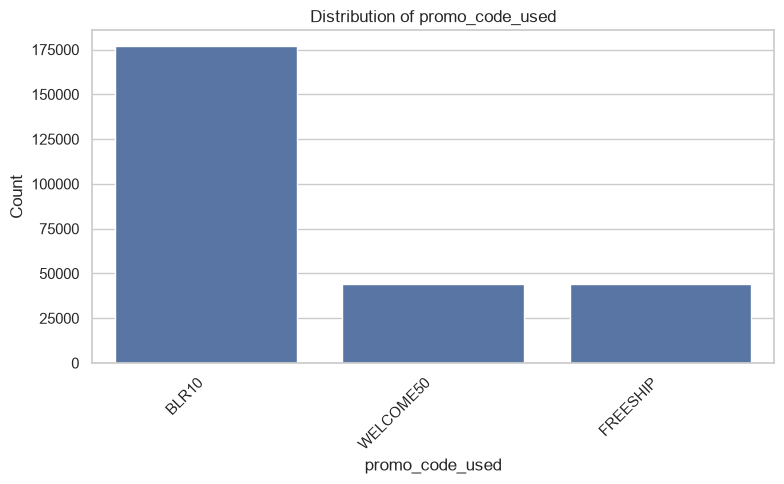

In [24]:
import numpy as np
from IPython.display import display

for name, df in [
    ("Restaurants", restaurants_df),
    ("Riders", riders_df),
    ("Orders", orders_df),
]:

    print("=" * 80)
    print(f"{name} Dataset — Univariate Analysis")
    print("=" * 80)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    # ==========================================================
    # Numerical Features
    # ==========================================================
    if numeric_cols:

        print("\nNumerical Features")

        for col in numeric_cols:

            print(f"\n{'-'*80}")
            print(f"Feature : {col}")
            print(f"{'-'*80}")

            series = df[col].dropna()

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))

            # Histogram
            ax[0].hist(series, bins=30, edgecolor="black")
            ax[0].set_title(f"Histogram - {col}")
            ax[0].set_xlabel(col)
            ax[0].set_ylabel("Frequency")

            # Box Plot
            ax[1].boxplot(series, patch_artist=True)
            ax[1].set_title(f"Box Plot - {col}")

            plt.tight_layout()
            plt.show()

            summary = pd.DataFrame({
                "Statistic": [
                    "Minimum",
                    "Maximum",
                    "Mean",
                    "Median",
                    "Standard Deviation",
                    "Skewness",
                    "Kurtosis",
                ],
                "Value": [
                    series.min(),
                    series.max(),
                    series.mean(),
                    series.median(),
                    series.std(),
                    series.skew(),
                    series.kurt(),
                ],
            })

            display(summary.round(2))

    else:
        print("No numerical features found.")

    # ==========================================================
    # Categorical Features
    # ==========================================================
    if categorical_cols:

        print("\nCategorical Features")

        for col in categorical_cols:

            print(f"\n{'-'*80}")
            print(f"Feature : {col}")
            print(f"{'-'*80}")

            # Convert safely to string
            plot_series = df[col].fillna("Missing").astype(str)

            counts = plot_series.value_counts()

            freq_table = pd.DataFrame({
                "Count": counts,
                "Percentage (%)": (counts / len(plot_series) * 100).round(2)
            })

            display(freq_table)

            # --------------------------------------------------
            # Low-cardinality categorical variables
            # --------------------------------------------------
            if counts.shape[0] <= 20:

                plt.figure(figsize=(8, 5))

                sns.countplot(
                    x=plot_series,
                    order=counts.index
                )

                plt.title(f"Distribution of {col}")
                plt.xlabel(col)
                plt.ylabel("Count")
                plt.xticks(rotation=45, ha="right")

                plt.tight_layout()
                plt.show()

            # --------------------------------------------------
            # High-cardinality categorical variables
            # --------------------------------------------------
            else:

                print(
                    f"{col} has {counts.shape[0]} unique values."
                )
                print("Displaying Top 10 categories only.\n")

                top10 = counts.head(10)

                plt.figure(figsize=(10, 5))

                sns.barplot(
                    x=top10.values,
                    y=top10.index
                )

                plt.title(f"Top 10 Most Frequent Values - {col}")
                plt.xlabel("Count")
                plt.ylabel(col)

                plt.tight_layout()
                plt.show()

    else:
        print("No categorical features found.")

    print("\n")

# 8. Bivariate Analysis

After understanding each feature individually, the next step is to study how individual features relate to the target variable.

The objective of this analysis is to identify variables that appear to influence delivery time and therefore may become important predictors during machine learning.

The analysis investigates relationships between numerical and categorical features with the target variable.

The insights obtained here help identify useful predictive features and potential feature engineering opportunities.